# Import Libraries

In [3]:
import warnings
warnings.filterwarnings("ignore")

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import pickle
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

for dirname,_,filenames in os.walk('splitted_data'):
    for filename in filenames:
        print(os.path.join(dirname,filename))

splitted_data\X_test.csv
splitted_data\X_train.csv
splitted_data\y_test.csv
splitted_data\y_train.csv


# Data Loading

In [4]:
X_train = pd.read_csv('splitted_data/X_train.csv')
X_test = pd.read_csv('splitted_data/X_test.csv')
y_train = pd.read_csv('splitted_data/y_train.csv')
y_test = pd.read_csv('splitted_data/y_test.csv')

print(X_train.shape ,X_test.shape, y_train.shape, y_test.shape)

(20468, 30) (5117, 30) (20468, 1) (5117, 1)


In [5]:
X_train.head()

,PSH Flag Count,Active Mean,Active Min,Active Max,Flow IAT Mean,Idle Std,Idle Max,Bwd Packets/s,Fwd IAT Std,Fwd IAT Max,...,Bwd IAT Max,Fwd PSH Flags,SYN Flag Count,Down/Up Ratio,Fwd IAT Mean,Bwd IAT Mean,Flow Packets/s,Flow Bytes/s,Active Std,Fwd Packet Length Min
0,0.0,0.0,0.0,0.0,5.344878e-03,0.0,0.0,0.000000,0.012840,1.795767e-02,...,0.000000e+00,0.0,0.0,0.0,4.491498e-03,0.000000e+00,7.729043e-07,7.086926e-09,0.0,0.003026
1,1.0,0.0,0.0,0.0,4.450000e-07,0.0,0.0,0.016667,0.000000,0.000000e+00,...,0.000000e+00,0.0,0.0,0.2,0.000000e+00,0.000000e+00,1.481481e-02,8.978676e-05,0.0,0.001009
2,0.0,0.0,0.0,0.0,5.197155e-03,0.0,0.0,0.000000,0.012480,1.745525e-02,...,0.000000e+00,0.0,0.0,0.0,4.367361e-03,0.000000e+00,7.950624e-07,7.288363e-09,0.0,0.003026
3,0.0,0.0,0.0,0.0,6.675464e-04,0.0,0.0,0.000000,0.002618,6.686277e-03,...,0.000000e+00,0.0,0.0,0.0,5.609675e-04,0.000000e+00,5.012063e-06,3.802061e-07,0.0,0.025214
4,0.0,0.0,0.0,0.0,6.450000e-07,0.0,0.0,0.007692,0.000000,3.361345e-08,...,4.033613e-07,0.0,0.0,0.2,3.361345e-08,4.033613e-07,6.837600e-03,1.046361e-03,0.0,0.018659


In [6]:
y_train.head()

,Label
0,2
1,4
2,2
3,0
4,0


---

# Algorithm 1 : Support Vector Classifier

***Model Initializing and Training***

In [ ]:
from sklearn.svm import SVC

svc_model = SVC() 

svc_model = svc_model.fit(X_train.values,y_train.values.ravel())

***Model Testing***

In [11]:
true_labels = y_test.values.ravel()
print(true_labels.tolist())

[3, 0, 2, 3, 0, 2, 1, 4, 0, 2, 3, 3, 2, 0, 1, 4, 2, 4, 4, 4, 2, 1, 2, 2, 3, 1, 2, 4, 0, 3, 2, 3, 3, 1, 2, 4, 0, 1, 2, 3, 0, 4, 2, 0, 2, 3, 2, 4, 4, 3, 1, 4, 0, 0, 4, 2, 1, 0, 1, 1, 0, 1, 0, 4, 0, 4, 4, 0, 0, 0, 1, 2, 3, 1, 0, 0, 3, 4, 1, 3, 2, 2, 4, 2, 3, 0, 0, 1, 2, 1, 3, 0, 1, 3, 2, 2, 2, 1, 2, 4, 4, 2, 4, 0, 2, 1, 4, 3, 4, 0, 2, 4, 3, 4, 0, 2, 4, 3, 4, 1, 1, 2, 4, 2, 3, 4, 0, 0, 1, 0, 0, 3, 0, 3, 2, 2, 2, 4, 4, 4, 4, 3, 0, 3, 0, 2, 3, 0, 4, 4, 0, 4, 4, 3, 3, 0, 2, 2, 0, 3, 0, 2, 3, 4, 0, 0, 4, 4, 3, 3, 0, 1, 2, 1, 1, 0, 4, 3, 1, 2, 0, 0, 2, 2, 2, 4, 1, 0, 1, 2, 2, 1, 1, 3, 2, 1, 2, 2, 2, 2, 2, 3, 2, 4, 2, 3, 2, 3, 4, 4, 4, 3, 0, 0, 0, 4, 3, 0, 2, 4, 1, 0, 3, 0, 2, 0, 0, 1, 0, 0, 4, 4, 3, 4, 4, 3, 0, 4, 4, 3, 1, 0, 0, 2, 0, 1, 1, 4, 0, 4, 4, 1, 3, 0, 4, 2, 1, 4, 2, 1, 1, 2, 1, 4, 2, 2, 4, 0, 2, 0, 4, 1, 2, 4, 4, 1, 3, 4, 4, 0, 4, 4, 2, 2, 2, 4, 3, 0, 2, 4, 3, 3, 1, 0, 2, 2, 3, 3, 2, 2, 1, 0, 4, 4, 2, 0, 3, 3, 3, 0, 2, 0, 4, 0, 4, 2, 1, 2, 0, 4, 2, 2, 3, 3, 4, 3, 0, 0, 1, 2, 2, 2, 1, 

### Result Analysis

In [12]:
class_indices = [0, 1, 2, 3, 4]  # Corresponding to class_labels below
class_labels = ['BENIGN', 'Brute Force', 'DDoS', 'DoS', 'PortScan']

***Accuracy Score***

In [13]:
svc_model_accuracy = accuracy_score(y_true=true_labels, y_pred=svc_prediction)
print("Validation accuracy of SupportVectorClassifier model is {:.2f}%".format(svc_model_accuracy*100))

Validation accuracy of SupportVectorClassifier model is 91.81%


***Classification Report***

In [14]:
print(classification_report(y_true=true_labels, y_pred=svc_prediction, target_names=class_labels))

              precision    recall  f1-score   support

      BENIGN       0.87      0.81      0.84      1024
 Brute Force       0.91      0.91      0.91      1023
        DDoS       0.86      1.00      0.92      1023
         DoS       0.97      0.94      0.95      1024
    PortScan       1.00      0.93      0.96      1023

    accuracy                           0.92      5117
   macro avg       0.92      0.92      0.92      5117
weighted avg       0.92      0.92      0.92      5117



***Confusion Matrix***

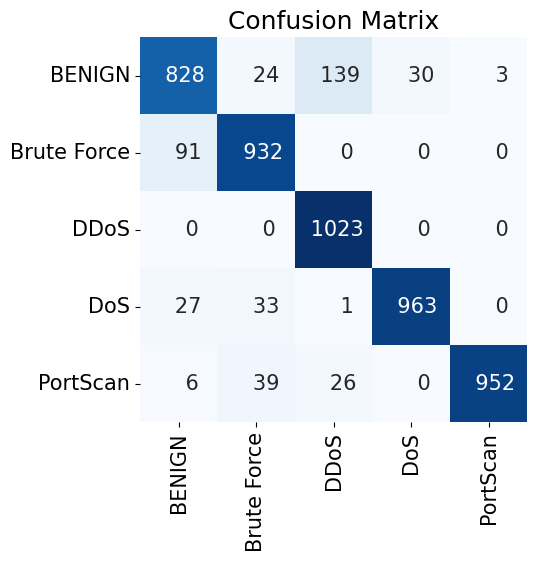

In [15]:
plt.figure(figsize=(5,5))
plt.rcParams['font.size'] = 15
sns.heatmap(data=confusion_matrix(y_true=true_labels, y_pred=svc_prediction),
            annot=True,
            cmap=plt.cm.Blues,
            fmt = "5d",
            xticklabels=class_labels,
            yticklabels=class_labels,
            cbar=False)
plt.title(label="Confusion Matrix")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

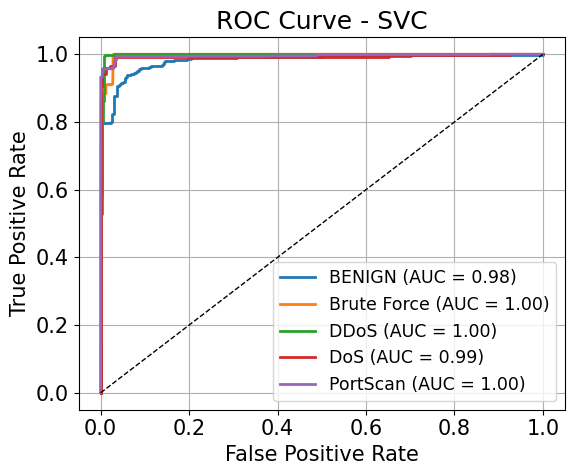

In [17]:
plot_multiclass_roc_curve(svc_model, X_test, y_test, class_indices, class_labels, title="ROC Curve - SVC")

***Model Saving***

In [18]:
with open(file="models/SupportVectorClassifier_model.pkl", mode="wb") as file:
    pickle.dump(obj=svc_model, file=file)

---

# Algorithm 2 : KNeighbors Classifier

***Model Initializing and Training***

In [19]:
from sklearn.neighbors import KNeighborsClassifier

# Initialize KNN model
knn_model = KNeighborsClassifier(n_neighbors=500)

# Fit the model
knn_model.fit(X_train.values, y_train.values.ravel())

KNeighborsClassifier(n_neighbors=500)

***Model Testing***

In [21]:
true_labels = y_test.values.ravel()
print(true_labels.tolist())

[3, 0, 2, 3, 0, 2, 1, 4, 0, 2, 3, 3, 2, 0, 1, 4, 2, 4, 4, 4, 2, 1, 2, 2, 3, 1, 2, 4, 0, 3, 2, 3, 3, 1, 2, 4, 0, 1, 2, 3, 0, 4, 2, 0, 2, 3, 2, 4, 4, 3, 1, 4, 0, 0, 4, 2, 1, 0, 1, 1, 0, 1, 0, 4, 0, 4, 4, 0, 0, 0, 1, 2, 3, 1, 0, 0, 3, 4, 1, 3, 2, 2, 4, 2, 3, 0, 0, 1, 2, 1, 3, 0, 1, 3, 2, 2, 2, 1, 2, 4, 4, 2, 4, 0, 2, 1, 4, 3, 4, 0, 2, 4, 3, 4, 0, 2, 4, 3, 4, 1, 1, 2, 4, 2, 3, 4, 0, 0, 1, 0, 0, 3, 0, 3, 2, 2, 2, 4, 4, 4, 4, 3, 0, 3, 0, 2, 3, 0, 4, 4, 0, 4, 4, 3, 3, 0, 2, 2, 0, 3, 0, 2, 3, 4, 0, 0, 4, 4, 3, 3, 0, 1, 2, 1, 1, 0, 4, 3, 1, 2, 0, 0, 2, 2, 2, 4, 1, 0, 1, 2, 2, 1, 1, 3, 2, 1, 2, 2, 2, 2, 2, 3, 2, 4, 2, 3, 2, 3, 4, 4, 4, 3, 0, 0, 0, 4, 3, 0, 2, 4, 1, 0, 3, 0, 2, 0, 0, 1, 0, 0, 4, 4, 3, 4, 4, 3, 0, 4, 4, 3, 1, 0, 0, 2, 0, 1, 1, 4, 0, 4, 4, 1, 3, 0, 4, 2, 1, 4, 2, 1, 1, 2, 1, 4, 2, 2, 4, 0, 2, 0, 4, 1, 2, 4, 4, 1, 3, 4, 4, 0, 4, 4, 2, 2, 2, 4, 3, 0, 2, 4, 3, 3, 1, 0, 2, 2, 3, 3, 2, 2, 1, 0, 4, 4, 2, 0, 3, 3, 3, 0, 2, 0, 4, 0, 4, 2, 1, 2, 0, 4, 2, 2, 3, 3, 4, 3, 0, 0, 1, 2, 2, 2, 1, 

### Result Analysis

***Accuracy Score***

In [22]:
knn_model_accuracy = accuracy_score(y_true=true_labels, y_pred=knn_prediction)
print("Validation accuracy of KNeighborsClassifier model is {:.2f}%".format(knn_model_accuracy * 100))

Validation accuracy of KNeighborsClassifier model is 92.50%


***Accuracy Score***

In [23]:
print(classification_report(y_true=true_labels, y_pred=knn_prediction, target_names=class_labels))

              precision    recall  f1-score   support

      BENIGN       0.94      0.78      0.85      1024
 Brute Force       0.88      0.99      0.93      1023
        DDoS       0.88      1.00      0.93      1023
         DoS       0.96      0.92      0.94      1024
    PortScan       0.98      0.93      0.96      1023

    accuracy                           0.92      5117
   macro avg       0.93      0.92      0.92      5117
weighted avg       0.93      0.92      0.92      5117



***Confusion Matrix***

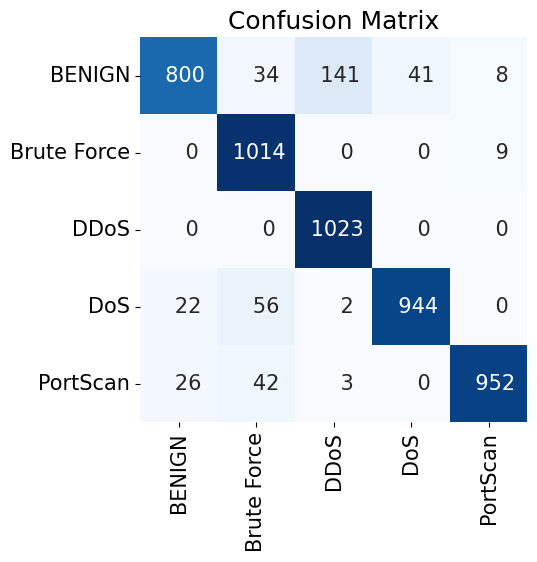

In [24]:
plt.figure(figsize=(5,5))
plt.rcParams['font.size'] = 15
sns.heatmap(data=confusion_matrix(y_true=true_labels, y_pred=knn_prediction),
            annot=True,
            cmap=plt.cm.Blues,
            fmt = "5d",
            xticklabels=class_labels,
            yticklabels=class_labels,
            cbar=False)
plt.title(label="Confusion Matrix")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

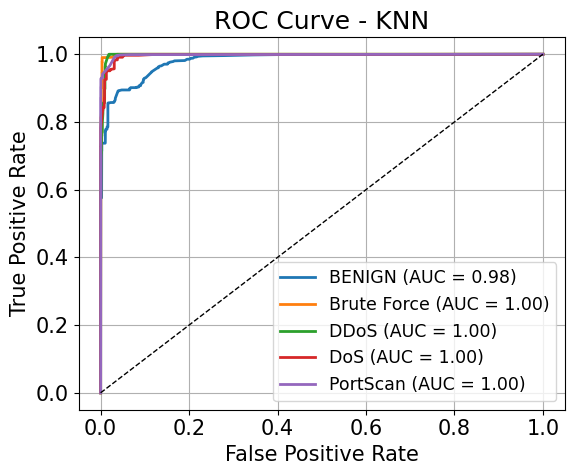

In [25]:
plot_multiclass_roc_curve(knn_model, X_test, y_test, class_indices, class_labels, title="ROC Curve - KNN")



***Model Saving***

In [26]:
with open("models/KNeighborsClassifier_model.pkl", "wb") as file:
    pickle.dump(knn_model, file)

# Algorithm 3 : Random Forest Classifier

In [27]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

In [28]:
rf_model.fit(X_train.values, y_train.values.ravel())

RandomForestClassifier(random_state=42)

***Model Testing***

In [30]:
true_labels = y_test.values.ravel()
print(true_labels.tolist())

[3, 0, 2, 3, 0, 2, 1, 4, 0, 2, 3, 3, 2, 0, 1, 4, 2, 4, 4, 4, 2, 1, 2, 2, 3, 1, 2, 4, 0, 3, 2, 3, 3, 1, 2, 4, 0, 1, 2, 3, 0, 4, 2, 0, 2, 3, 2, 4, 4, 3, 1, 4, 0, 0, 4, 2, 1, 0, 1, 1, 0, 1, 0, 4, 0, 4, 4, 0, 0, 0, 1, 2, 3, 1, 0, 0, 3, 4, 1, 3, 2, 2, 4, 2, 3, 0, 0, 1, 2, 1, 3, 0, 1, 3, 2, 2, 2, 1, 2, 4, 4, 2, 4, 0, 2, 1, 4, 3, 4, 0, 2, 4, 3, 4, 0, 2, 4, 3, 4, 1, 1, 2, 4, 2, 3, 4, 0, 0, 1, 0, 0, 3, 0, 3, 2, 2, 2, 4, 4, 4, 4, 3, 0, 3, 0, 2, 3, 0, 4, 4, 0, 4, 4, 3, 3, 0, 2, 2, 0, 3, 0, 2, 3, 4, 0, 0, 4, 4, 3, 3, 0, 1, 2, 1, 1, 0, 4, 3, 1, 2, 0, 0, 2, 2, 2, 4, 1, 0, 1, 2, 2, 1, 1, 3, 2, 1, 2, 2, 2, 2, 2, 3, 2, 4, 2, 3, 2, 3, 4, 4, 4, 3, 0, 0, 0, 4, 3, 0, 2, 4, 1, 0, 3, 0, 2, 0, 0, 1, 0, 0, 4, 4, 3, 4, 4, 3, 0, 4, 4, 3, 1, 0, 0, 2, 0, 1, 1, 4, 0, 4, 4, 1, 3, 0, 4, 2, 1, 4, 2, 1, 1, 2, 1, 4, 2, 2, 4, 0, 2, 0, 4, 1, 2, 4, 4, 1, 3, 4, 4, 0, 4, 4, 2, 2, 2, 4, 3, 0, 2, 4, 3, 3, 1, 0, 2, 2, 3, 3, 2, 2, 1, 0, 4, 4, 2, 0, 3, 3, 3, 0, 2, 0, 4, 0, 4, 2, 1, 2, 0, 4, 2, 2, 3, 3, 4, 3, 0, 0, 1, 2, 2, 2, 1, 

***Result Analysis***

In [31]:
# Accuracy Score
rf_model_accuracy = accuracy_score(y_true=true_labels, y_pred=rf_prediction)
print("Validation accuracy of RandomForestClassifier model is {:.2f}%".format(rf_model_accuracy * 100))

Validation accuracy of RandomForestClassifier model is 99.75%


In [32]:
# Classification Report
print(classification_report(y_true=true_labels, y_pred=rf_prediction, target_names=class_labels))

              precision    recall  f1-score   support

      BENIGN       0.99      1.00      0.99      1024
 Brute Force       1.00      1.00      1.00      1023
        DDoS       1.00      1.00      1.00      1023
         DoS       1.00      1.00      1.00      1024
    PortScan       1.00      1.00      1.00      1023

    accuracy                           1.00      5117
   macro avg       1.00      1.00      1.00      5117
weighted avg       1.00      1.00      1.00      5117



In [33]:
def plot_confusion_matrix(y_true, y_pred, class_labels, title="Confusion Matrix"):
    plt.figure(figsize=(5, 5))
    plt.rcParams['font.size'] = 15
    sns.heatmap(
        data=confusion_matrix(y_true=y_true, y_pred=y_pred),
        annot=True,
        cmap=plt.cm.Blues,
        fmt="5d",
        xticklabels=class_labels,
        yticklabels=class_labels,
        cbar=False
    )
    plt.title(title)
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

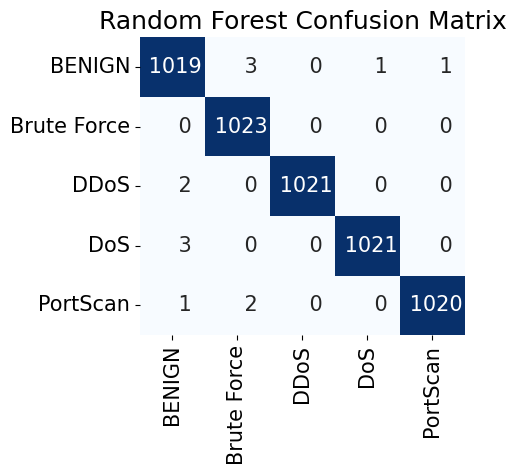

In [34]:
plot_confusion_matrix(
    y_true=true_labels,
    y_pred=rf_prediction,
    class_labels=class_labels,
    title="Random Forest Confusion Matrix"
)


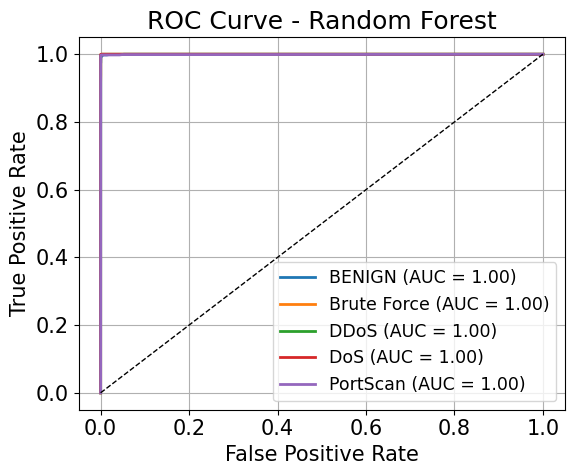

In [35]:
plot_multiclass_roc_curve(rf_model, X_test, y_test, class_indices, class_labels, title="ROC Curve - Random Forest")


***Model Saving***

In [36]:
with open("models/RandomForestClassifier_model.pkl", "wb") as file:
    pickle.dump(rf_model, file)

# Model 4:Naive Bayes Classifier

In [38]:
nb_model.fit(X_train.values, y_train.values.ravel())

GaussianNB()

***Model Testing***

In [40]:
true_labels = y_test.values.ravel()
print(true_labels.tolist())

[3, 0, 2, 3, 0, 2, 1, 4, 0, 2, 3, 3, 2, 0, 1, 4, 2, 4, 4, 4, 2, 1, 2, 2, 3, 1, 2, 4, 0, 3, 2, 3, 3, 1, 2, 4, 0, 1, 2, 3, 0, 4, 2, 0, 2, 3, 2, 4, 4, 3, 1, 4, 0, 0, 4, 2, 1, 0, 1, 1, 0, 1, 0, 4, 0, 4, 4, 0, 0, 0, 1, 2, 3, 1, 0, 0, 3, 4, 1, 3, 2, 2, 4, 2, 3, 0, 0, 1, 2, 1, 3, 0, 1, 3, 2, 2, 2, 1, 2, 4, 4, 2, 4, 0, 2, 1, 4, 3, 4, 0, 2, 4, 3, 4, 0, 2, 4, 3, 4, 1, 1, 2, 4, 2, 3, 4, 0, 0, 1, 0, 0, 3, 0, 3, 2, 2, 2, 4, 4, 4, 4, 3, 0, 3, 0, 2, 3, 0, 4, 4, 0, 4, 4, 3, 3, 0, 2, 2, 0, 3, 0, 2, 3, 4, 0, 0, 4, 4, 3, 3, 0, 1, 2, 1, 1, 0, 4, 3, 1, 2, 0, 0, 2, 2, 2, 4, 1, 0, 1, 2, 2, 1, 1, 3, 2, 1, 2, 2, 2, 2, 2, 3, 2, 4, 2, 3, 2, 3, 4, 4, 4, 3, 0, 0, 0, 4, 3, 0, 2, 4, 1, 0, 3, 0, 2, 0, 0, 1, 0, 0, 4, 4, 3, 4, 4, 3, 0, 4, 4, 3, 1, 0, 0, 2, 0, 1, 1, 4, 0, 4, 4, 1, 3, 0, 4, 2, 1, 4, 2, 1, 1, 2, 1, 4, 2, 2, 4, 0, 2, 0, 4, 1, 2, 4, 4, 1, 3, 4, 4, 0, 4, 4, 2, 2, 2, 4, 3, 0, 2, 4, 3, 3, 1, 0, 2, 2, 3, 3, 2, 2, 1, 0, 4, 4, 2, 0, 3, 3, 3, 0, 2, 0, 4, 0, 4, 2, 1, 2, 0, 4, 2, 2, 3, 3, 4, 3, 0, 0, 1, 2, 2, 2, 1, 

***Result Analysis***

In [41]:
# Accuracy Score
nb_model_accuracy = accuracy_score(y_true=true_labels, y_pred=nb_prediction)
print("Validation accuracy of GaussianNB model is {:.2f}%".format(nb_model_accuracy * 100))

Validation accuracy of GaussianNB model is 84.89%


In [42]:
# Classification Report
print(classification_report(y_true=true_labels, y_pred=nb_prediction, target_names=class_labels))

              precision    recall  f1-score   support

      BENIGN       0.98      0.86      0.92      1024
 Brute Force       0.90      1.00      0.95      1023
        DDoS       0.94      0.50      0.65      1023
         DoS       0.96      0.90      0.93      1024
    PortScan       0.64      0.98      0.77      1023

    accuracy                           0.85      5117
   macro avg       0.88      0.85      0.84      5117
weighted avg       0.88      0.85      0.84      5117



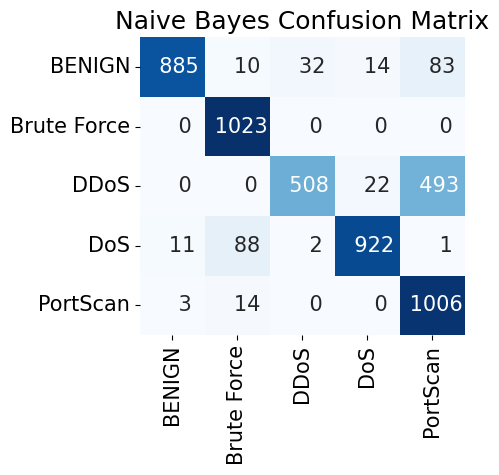

In [43]:
# Confusion Matrix (using the function we defined earlier)
plot_confusion_matrix(
    y_true=true_labels,
    y_pred=nb_prediction,
    class_labels=class_labels,
    title="Naive Bayes Confusion Matrix"
)

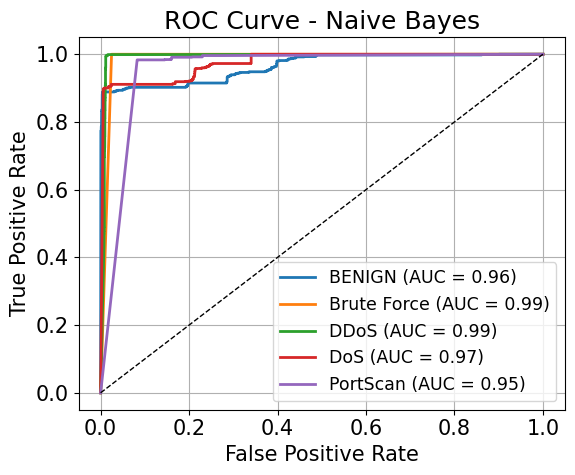

In [44]:
plot_multiclass_roc_curve(nb_model, X_test, y_test, class_indices, class_labels, title="ROC Curve - Naive Bayes")

***Model Saving***


In [45]:
with open("models/GaussianNB_model.pkl", "wb") as file:
    pickle.dump(nb_model, file)

# Model 5:Logistic Regression Classifier

In [47]:
lr_model.fit(X_train.values, y_train.values.ravel())

LogisticRegression(max_iter=1000, random_state=42)

***Model Testing***

In [49]:
true_labels = y_test.values.ravel()
print(true_labels.tolist())

[3, 0, 2, 3, 0, 2, 1, 4, 0, 2, 3, 3, 2, 0, 1, 4, 2, 4, 4, 4, 2, 1, 2, 2, 3, 1, 2, 4, 0, 3, 2, 3, 3, 1, 2, 4, 0, 1, 2, 3, 0, 4, 2, 0, 2, 3, 2, 4, 4, 3, 1, 4, 0, 0, 4, 2, 1, 0, 1, 1, 0, 1, 0, 4, 0, 4, 4, 0, 0, 0, 1, 2, 3, 1, 0, 0, 3, 4, 1, 3, 2, 2, 4, 2, 3, 0, 0, 1, 2, 1, 3, 0, 1, 3, 2, 2, 2, 1, 2, 4, 4, 2, 4, 0, 2, 1, 4, 3, 4, 0, 2, 4, 3, 4, 0, 2, 4, 3, 4, 1, 1, 2, 4, 2, 3, 4, 0, 0, 1, 0, 0, 3, 0, 3, 2, 2, 2, 4, 4, 4, 4, 3, 0, 3, 0, 2, 3, 0, 4, 4, 0, 4, 4, 3, 3, 0, 2, 2, 0, 3, 0, 2, 3, 4, 0, 0, 4, 4, 3, 3, 0, 1, 2, 1, 1, 0, 4, 3, 1, 2, 0, 0, 2, 2, 2, 4, 1, 0, 1, 2, 2, 1, 1, 3, 2, 1, 2, 2, 2, 2, 2, 3, 2, 4, 2, 3, 2, 3, 4, 4, 4, 3, 0, 0, 0, 4, 3, 0, 2, 4, 1, 0, 3, 0, 2, 0, 0, 1, 0, 0, 4, 4, 3, 4, 4, 3, 0, 4, 4, 3, 1, 0, 0, 2, 0, 1, 1, 4, 0, 4, 4, 1, 3, 0, 4, 2, 1, 4, 2, 1, 1, 2, 1, 4, 2, 2, 4, 0, 2, 0, 4, 1, 2, 4, 4, 1, 3, 4, 4, 0, 4, 4, 2, 2, 2, 4, 3, 0, 2, 4, 3, 3, 1, 0, 2, 2, 3, 3, 2, 2, 1, 0, 4, 4, 2, 0, 3, 3, 3, 0, 2, 0, 4, 0, 4, 2, 1, 2, 0, 4, 2, 2, 3, 3, 4, 3, 0, 0, 1, 2, 2, 2, 1, 

***Result Analysis***


In [50]:
# Accuracy Score
lr_model_accuracy = accuracy_score(y_true=true_labels, y_pred=lr_prediction)
print("Validation accuracy of LogisticRegression model is {:.2f}%".format(lr_model_accuracy * 100))

Validation accuracy of LogisticRegression model is 91.07%


In [51]:
# Classification Report
print(classification_report(y_true=true_labels, y_pred=lr_prediction, target_names=class_labels))

              precision    recall  f1-score   support

      BENIGN       0.80      0.83      0.82      1024
 Brute Force       0.93      0.91      0.92      1023
        DDoS       0.87      0.90      0.89      1023
         DoS       0.99      0.94      0.96      1024
    PortScan       0.98      0.97      0.97      1023

    accuracy                           0.91      5117
   macro avg       0.91      0.91      0.91      5117
weighted avg       0.91      0.91      0.91      5117



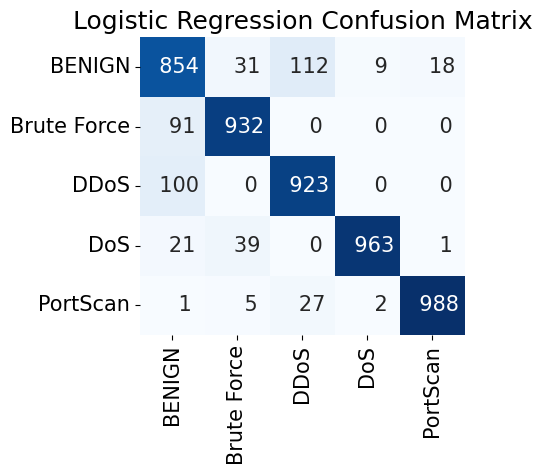

In [52]:
# Confusion Matrix
plot_confusion_matrix(
    y_true=true_labels,
    y_pred=lr_prediction,
    class_labels=class_labels,
    title="Logistic Regression Confusion Matrix"
)

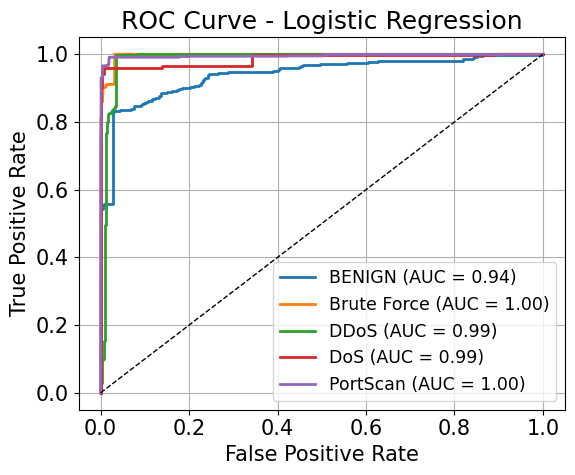

In [53]:
plot_multiclass_roc_curve(lr_model, X_test, y_test, class_indices, class_labels, title="ROC Curve - Logistic Regression")


***Model Saving***

In [54]:
with open("models/LogisticRegression_model.pkl", "wb") as file:
    pickle.dump(lr_model, file)

---